# Project 2：NASA Data Acquisation, Visualization, and Analysis
![NASA Orbit](nasa_orbit.png)

### Task 1: Understanding the NASA API and Data Collection

- Run the Python script below to fetch data about **Near Earth Objects (NEOs)**.
- Extract and understand the different pieces of data provided for each NEO.

In [1]:
import sys
import subprocess

# Function to install a package
def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Check if gdown is installed, and install it if not
try:
    import gdown
except ImportError:
    install('gdown')
    import gdown

import pickle

In [2]:
# Google Drive file ID
file_id = '1iW47qh3E2ccZVQ4fOs9-UP0xNEjhNae2'
# URL to the file
url = f'https://drive.google.com/uc?export=download&id={file_id}'

# Output file name
output = 'file.pkl'

# Download the file
gdown.download(url, output, quiet=False)

# Load the pickle file
with open(output, 'rb') as f:
    data = pickle.load(f)

Downloading...
From: https://drive.google.com/uc?export=download&id=1iW47qh3E2ccZVQ4fOs9-UP0xNEjhNae2
To: c:\Users\admin\OneDrive - Danmarks Tekniske Universitet\62444-Project-Course\62444-Data-Visualistation\file.pkl
100%|██████████| 5.26M/5.26M [00:00<00:00, 20.3MB/s]


*The code (commented out) below is for getting the data for arbitrary time span. If you would like some other data rather than the provided data above, feel free to try. But this is not mandatory.*

In order to use it, you need to get an API KEY from the website https://api.nasa.gov/.


In [3]:
# import requests
# import time
# from datetime import datetime, timedelta
# from getpass import getpass

# # Set your NASA API KEY, this step asks you to enter your API KEY.
# # (The input box may be float in the top on your editor.)
# api_key = getpass()

In [4]:
# # Set the start and end dates for the data you want to fetch
# start_date = datetime.strptime('2022-01-01', '%Y-%m-%d')
# end_date = start_date + timedelta(days=365)  # 1 year later

# # Initialize a list to store the data
# data = []

# # Fetch data from the NASA API 7 days at a time
# # The introduction of the API is on https://api.nasa.gov, under "Browse APIs" -> "Asteroids NeoWs"
# # You can look into the example query in the link below to see what the data look like:
# # https://api.nasa.gov/neo/rest/v1/feed?start_date=2015-09-07&end_date=2015-09-08&api_key=DEMO_KEY
# current_date = start_date
# while current_date < end_date:
#     next_date = min(current_date + timedelta(days=7), end_date)
#     response = requests.get(f'https://api.nasa.gov/neo/rest/v1/feed?start_date={current_date.strftime("%Y-%m-%d")}&end_date={next_date.strftime("%Y-%m-%d")}&api_key={api_key}')
#     data.append(response.json())
#     current_date = next_date
#     time.sleep(1)  # To avoid hitting the rate limit

# # Now 'data' contains the NEO data for the 1-year period


In [5]:
# Check the date coverage of your data.
dates_contained_in_data = []
for d in data:
    dates_contained_in_data += list(d['near_earth_objects'].keys())

print(sorted(dates_contained_in_data))

['2022-01-01', '2022-01-02', '2022-01-03', '2022-01-04', '2022-01-05', '2022-01-06', '2022-01-07', '2022-01-08', '2022-01-08', '2022-01-09', '2022-01-10', '2022-01-11', '2022-01-12', '2022-01-13', '2022-01-14', '2022-01-15', '2022-01-15', '2022-01-16', '2022-01-17', '2022-01-18', '2022-01-19', '2022-01-20', '2022-01-21', '2022-01-22', '2022-01-22', '2022-01-23', '2022-01-24', '2022-01-25', '2022-01-26', '2022-01-27', '2022-01-28', '2022-01-29', '2022-01-29', '2022-01-30', '2022-01-31', '2022-02-01', '2022-02-02', '2022-02-03', '2022-02-04', '2022-02-05', '2022-02-05', '2022-02-06', '2022-02-07', '2022-02-08', '2022-02-09', '2022-02-10', '2022-02-11', '2022-02-12', '2022-02-12', '2022-02-13', '2022-02-14', '2022-02-15', '2022-02-16', '2022-02-17', '2022-02-18', '2022-02-19', '2022-02-19', '2022-02-20', '2022-02-21', '2022-02-22', '2022-02-23', '2022-02-24', '2022-02-25', '2022-02-26', '2022-02-26', '2022-02-27', '2022-02-28', '2022-03-01', '2022-03-02', '2022-03-03', '2022-03-04', '2022

In [6]:
import numpy as np
def get_a_random_chunk_property(data):
    """
    This function only serves an example of fetching some of the properties
    from the data.
    Indeed, all the content in "data" may be useful for your project!
    """

    chunk_index = np.random.choice(len(data))

    date_list = list(data[chunk_index]["near_earth_objects"].keys())

    date = np.random.choice(date_list)

    objects_data = data[chunk_index]["near_earth_objects"][date]

    object_index = np.random.choice(len(objects_data))

    object = objects_data[object_index]

    properties = list(object.keys())
    property = np.random.choice(properties)

    print("date:", date)
    print("NEO name:", object["name"])
    print(f"{property}:", object[property])

In [7]:
import numpy as np
get_a_random_chunk_property(data)

date: 2022-10-27
NEO name: (2022 UB8)
nasa_jpl_url: http://ssd.jpl.nasa.gov/sbdb.cgi?sstr=54319882


### Task 2: Data Analysis

For the remaining tasks, you have to organize the data as pd.DataFrame so as to suit the specific need in each task. This part may require a considerably amount of efforts, which is normal in data science and analytics works.

**Remark**. This part is **coding intensive**. There is **NOT** any magic way to extract the data by one or two lines of code. Instead, you're expected to write your own code for this purpose.

- Calculate the average size of the NEOs for each day.（You have to fetch the corresponding each day's NEO size information from "data" by writing your own code)
- Determine the proportion of NEOs that are potentially hazardous.
- Find the NEO with the closest approach distance for each day.
- Use statistical methods to analyze the data. Calculate the mean, median, mode, and standard deviation of the NEO sizes. Besides, define at least two other statistic and compute them for anlayzing the data further.
- Use statistical methods to determine if the size of a NEO is correlated with whether it is potentially hazardous.

In [8]:
import numpy as np
import pandas as pd
from scipy import stats

# ── 1. Build a flat DataFrame with one row per NEO ───────────────────────────

rows = []

for chunk in data:
    for date, neos in chunk['near_earth_objects'].items():
        for neo in neos:
            est = neo['estimated_diameter']['kilometers']
            size_min = est['estimated_diameter_min']
            size_max = est['estimated_diameter_max']
            size_avg = (size_min + size_max) / 2

            approaches = neo['close_approach_data']
            miss_km = (
                float(approaches[0]['miss_distance']['kilometers'])
                if approaches else np.nan
            )

            rows.append({
                'date':          date,
                'name':          neo['name'],
                'size_avg_km':   size_avg,
                'size_min_km':   size_min,
                'size_max_km':   size_max,
                'hazardous':     neo['is_potentially_hazardous_asteroid'],
                'miss_dist_km':  miss_km,
            })

df = pd.DataFrame(rows)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(df.shape)
print(df.head(3))


(7914, 7)
        date        name  size_avg_km  size_min_km  size_max_km  hazardous  \
0 2022-01-01   (2021 YT)     0.122333     0.075606     0.169060      False   
1 2022-01-01  (2019 NP5)     0.012988     0.008027     0.017949      False   
2 2022-01-01  (2019 XK1)     0.027136     0.016771     0.037501      False   

   miss_dist_km  
0  4.058035e+07  
1  6.269817e+07  
2  3.494352e+07  


In [9]:
# ── 2. Average NEO size per day ───────────────────────────────────────────────

avg_size_per_day = (
    df.groupby('date')['size_avg_km']
    .mean()
    .reset_index()
    .rename(columns={'size_avg_km': 'avg_size_km'})
)

print("\nAverage NEO size per day (first 5 rows):")
print(avg_size_per_day.head())



Average NEO size per day (first 5 rows):
        date  avg_size_km
0 2022-01-01     0.164070
1 2022-01-02     0.113284
2 2022-01-03     0.028179
3 2022-01-04     0.080179
4 2022-01-05     0.177149


In [10]:
# ── 3. Proportion of potentially hazardous NEOs ───────────────────────────────

n_total     = len(df)
n_hazardous = df['hazardous'].sum()
proportion  = n_hazardous / n_total

print(f"\nTotal NEOs: {n_total}")
print(f"Hazardous:  {n_hazardous}")
print(f"Proportion: {proportion:.4f}  ({proportion*100:.2f} %)")



Total NEOs: 7914
Hazardous:  508
Proportion: 0.0642  (6.42 %)


In [11]:
# ── 4. NEO with closest approach distance for each day ───────────────────────

closest_per_day = (
    df.loc[df.groupby('date')['miss_dist_km'].idxmin()]
    [['date', 'name', 'miss_dist_km']]
    .reset_index(drop=True))
print("\nClosest NEO per day (first 5 rows):")
print(closest_per_day.head())


Closest NEO per day (first 5 rows):
        date         name  miss_dist_km
0 2022-01-01   (2022 AJ1)  7.705295e+05
1 2022-01-02   (2022 AP1)  1.805971e+05
2 2022-01-03    (2022 AU)  3.185179e+05
3 2022-01-04   (2022 AT1)  2.041259e+06
4 2022-01-05  (2022 AV13)  1.094803e+05


In [12]:
# ── 5. Descriptive statistics on NEO sizes ────────────────────────────────────

sizes = df['size_avg_km']

mean_size   = float(sizes.mean())
median_size = float(sizes.median())
mode_size   = float(sizes.mode().iloc[0])
std_size    = float(sizes.std())

In [13]:
# Additional statistics
skewness = float(sizes.skew())          # asymmetry of the distribution
iqr      = float(sizes.quantile(0.75) - sizes.quantile(0.25))  # spread of middle 50 %

print("\n── Descriptive statistics for NEO size (km) ──")
print(f"Mean:      {mean_size:.6f}")
print(f"Median:    {median_size:.6f}")
print(f"Mode:      {mode_size:.6f}")
print(f"Std dev:   {std_size:.6f}")
print(f"Skewness:  {skewness:.4f}  (positive → right-skewed distribution)")
print(f"IQR:       {iqr:.6f}  (robust spread, not affected by outliers)")


── Descriptive statistics for NEO size (km) ──
Mean:      0.150769
Median:    0.055660
Mode:      0.034162
Std dev:   0.295886
Skewness:  6.0819  (positive → right-skewed distribution)
IQR:       0.123724  (robust spread, not affected by outliers)


In [14]:
# ── 6. Correlation: NEO size vs. potentially hazardous ───────────────────────

# Convert boolean to int (1 = hazardous, 0 = not)
df['hazardous_int'] = df['hazardous'].astype(int)

# Point-biserial correlation (size is continuous, hazardous is binary)
corr, p_value = stats.pointbiserialr(df['hazardous_int'], df['size_avg_km'])

print("\n── Correlation: size vs. hazardousness ──")
print(f"Point-biserial r = {corr:.4f}")
print(f"p-value          = {p_value:.4e}")

if p_value < 0.05:
    print("Statistically significant correlation (p < 0.05).")
    if corr > 0:
        print("Larger NEOs tend to be more potentially hazardous.")
    else:
        print("Larger NEOs tend to be less potentially hazardous.")
else:
    print("No statistically significant correlation found (p >= 0.05).")

# Group means for intuition
print("\nMean size by hazard category:")
print(df.groupby('hazardous')['size_avg_km'].mean().rename({False: 'Non-hazardous', True: 'Hazardous'}))


── Correlation: size vs. hazardousness ──
Point-biserial r = 0.2565
p-value          = 3.9863e-119
Statistically significant correlation (p < 0.05).
Larger NEOs tend to be more potentially hazardous.

Mean size by hazard category:
hazardous
Non-hazardous    0.130892
Hazardous        0.440553
Name: size_avg_km, dtype: float64


**Textbook Practice**: Make a visualization as an evidence for your conclusion on the hazardousness. Apply the principle of "choosing an effective visual" in Chapter 2 to make this visualization. You need to explain how the principles below are used for making this plot:
- "Choose an appropriate display" (Chapter 2)
- "Eliminate clutter" (Chapter 3)
- "Draw attention there you want it" (Chapter 4)
- "Think like a designer" (Chapter 5)

## "Answer" Textbook Practice – Visualization of NEO Hazardousness

The plot shows the size distribution (estimated average diameter in km) for hazardous vs. non-hazardous NEOs, using overlapping histograms with dashed mean lines.

**Choose an appropriate display (Chapter 2)**
The goal is to compare two distributions to support the conclusion that hazardous NEOs tend to be larger. An overlapping histogram is the right choice: it lets the audience see both the shape of each distribution and where the two groups overlap or diverge. A bar chart of means alone would hide the spread, and a scatter plot would obscure density.

**Eliminate clutter (Chapter 3)**
The top and right axis spines are removed, keeping only the axes needed to read values. There is no grid, no background shading, and no box around the legend. Every element that remains serves the message — nothing is decorative.

**Draw attention where you want it (Chapter 4)**
Preattentive attributes guide the eye to the key finding. The hazardous group is rendered in saturated red at higher opacity, while non-hazardous uses neutral grey. Red stands out immediately without requiring a legend lookup. The dashed mean lines with bold/plain labels reinforce the contrast, and the title states the conclusion directly — *"Potentially hazardous NEOs are larger on average"* — before the reader even inspects the plot.

**Think like a designer (Chapter 5)**
*Affordances*: the histogram is a familiar format requiring no explanation. *Accessibility*: red vs. grey avoids red/green colorblindness issues, and mean values are annotated as text so the comparison does not rely on color alone. *Aesthetics*: tight layout, consistent font sizes, and a clean white background make the plot presentation-ready.

### Task 3: Data Visualization Part A

- Create a line plot of the number of NEOs per week.
- Create a histogram of the distribution of NEO sizes.
- Create a bar plot of the average NEO size per week.
- Use a library like Seaborn to create more complex visualizations, such as a box plot of the NEO sizes or a heat map of the number of NEOs per week. **Be creative**!

In [15]:
# ── Count NEOs per week ──────────────────────────────────────────────────────

df['week'] = df['date'].dt.to_period('W').dt.start_time

neos_per_week = (
    df.groupby('week')
    .size()
    .reset_index(name='count')
)

# Also create the weekly averages that will be used later
avg_size_per_week = (
    df.groupby('week')['size_avg_km']
    .mean()
    .reset_index()
    .rename(columns={'size_avg_km': 'size_avg_km'})
)
avg_size_per_week['week'] = neos_per_week['week']

print("\nNEOs per week (first 5 rows):")
print(neos_per_week.head())



NEOs per week (first 5 rows):
        week  count
0 2021-12-27     36
1 2022-01-03    117
2 2022-01-10    147
3 2022-01-17    138
4 2022-01-24    157


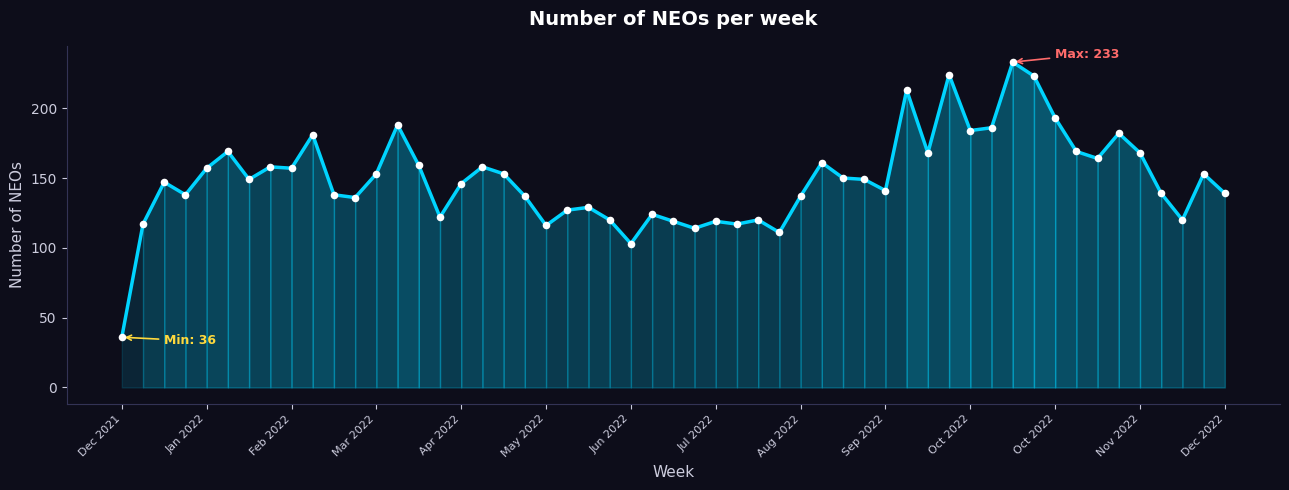

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# ── Fælles dark theme helper ──────────────────────────────────────────────────

def apply_dark_theme(fig, ax):
    fig.patch.set_facecolor('#0d0d1a')
    ax.set_facecolor('#0d0d1a')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333355')
    ax.spines['bottom'].set_color('#333355')
    ax.tick_params(colors='#ccccdd')
    ax.xaxis.label.set_color('#ccccdd')
    ax.yaxis.label.set_color('#ccccdd')
    ax.title.set_color('white')


# ── 1. Line plot: NEOs per week ───────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(13, 5))
apply_dark_theme(fig, ax)

x = np.arange(len(neos_per_week))
y = neos_per_week['count'].values

# Gradient fill under kurven
for i in range(len(x) - 1):
    ax.fill_between(x[i:i+2], y[i:i+2], alpha=0.08 + 0.3 * (y[i] / y.max()),
                    color='#00d4ff')

ax.plot(x, y, color='#00d4ff', linewidth=2.5, zorder=3)
ax.scatter(x, y, color='white', s=30, zorder=4, linewidths=0)

# Annotér kun min og max
ax.annotate(f'Max: {y.max()}',
            xy=(x[y.argmax()], y.max()),
            xytext=(x[y.argmax()] + 2, y.max() + 3),
            color='#ff6b6b', fontsize=9, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#ff6b6b', lw=1.2))

ax.annotate(f'Min: {y.min()}',
            xy=(x[y.argmin()], y.min()),
            xytext=(x[y.argmin()] + 2, y.min() - 5),
            color='#ffd93d', fontsize=9, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#ffd93d', lw=1.2))

ax.set_xticks(x[::4])
ax.set_xticklabels(neos_per_week['week'].iloc[::4].dt.strftime('%b %Y'),
                   rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Week', fontsize=11)
ax.set_ylabel('Number of NEOs', fontsize=11)
ax.set_title('Number of NEOs per week', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('neos_per_week.png', dpi=150, bbox_inches='tight')
plt.show()


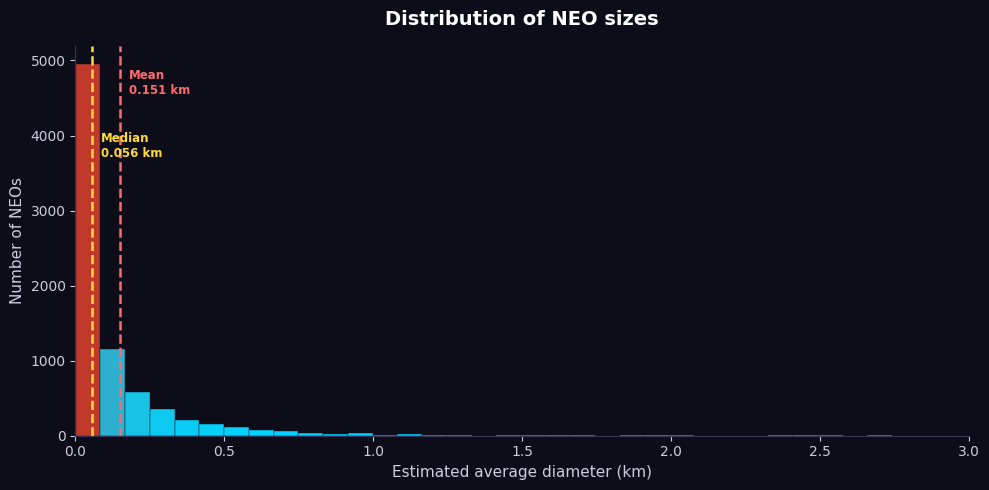

In [17]:
# ── 2. Histogram: NEO size distribution ──────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))
apply_dark_theme(fig, ax)

counts, bin_edges, patches = ax.hist(df['size_avg_km'], bins=60,
                                     edgecolor='#0d0d1a', linewidth=0.3)

# Farv søjlerne efter højde med gradient
cmap = LinearSegmentedColormap.from_list('neo', ['#00d4ff', '#c0392b'])
max_count = counts.max()
for patch, count in zip(patches, counts):
    patch.set_facecolor(cmap(count / max_count))

ax.set_xlim(0, 3)

mean_val   = df['size_avg_km'].mean()
median_val = df['size_avg_km'].median()

ax.axvline(mean_val,   color='#ff6b6b', linewidth=1.8, linestyle='--')
ax.axvline(median_val, color='#ffd93d', linewidth=1.8, linestyle='--')
ax.text(mean_val   + 0.03, counts.max() * 0.92, f'Mean\n{mean_val:.3f} km',
        color='#ff6b6b', fontsize=8.5, fontweight='bold')
ax.text(median_val + 0.03, counts.max() * 0.75, f'Median\n{median_val:.3f} km',
        color='#ffd93d', fontsize=8.5, fontweight='bold')

ax.set_xlabel('Estimated average diameter (km)', fontsize=11)
ax.set_ylabel('Number of NEOs', fontsize=11)
ax.set_title('Distribution of NEO sizes', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('neo_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

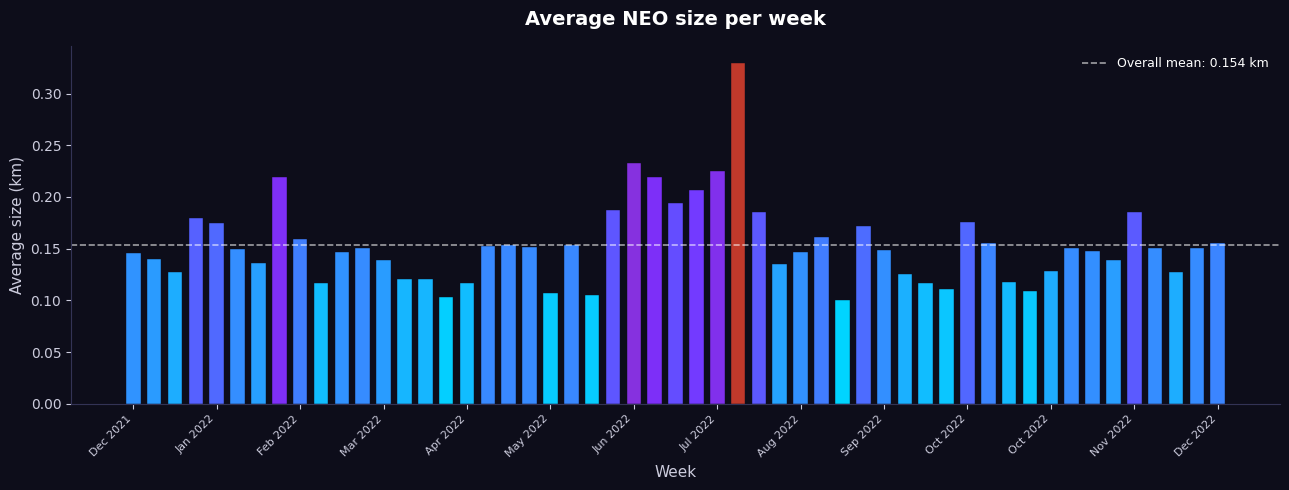

In [18]:
# ── 3. Bar plot: average NEO size per week ────────────────────────────────────

fig, ax = plt.subplots(figsize=(13, 5))
apply_dark_theme(fig, ax)

x      = np.arange(len(avg_size_per_week))
values = avg_size_per_week['size_avg_km'].values
grand_mean = values.mean()

# Farv søjler efter afvigelse fra gennemsnit
norm_vals = (values - values.min()) / (values.max() - values.min())
cmap2 = LinearSegmentedColormap.from_list('bar', ['#00d4ff', '#7b2fff', '#c0392b'])

bars = ax.bar(x, values, width=0.7, color=[cmap2(v) for v in norm_vals],
              edgecolor='#0d0d1a', linewidth=0.3)

ax.axhline(grand_mean, color='white', linewidth=1.2, linestyle='--', alpha=0.6,
           label=f'Overall mean: {grand_mean:.3f} km')
ax.legend(frameon=False, fontsize=9, labelcolor='white')

ax.set_xticks(x[::4])
ax.set_xticklabels(avg_size_per_week['week'].iloc[::4].dt.strftime('%b %Y'),
                   rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Week', fontsize=11)
ax.set_ylabel('Average size (km)', fontsize=11)
ax.set_title('Average NEO size per week', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('avg_neo_size_per_week.png', dpi=150, bbox_inches='tight')
plt.show()

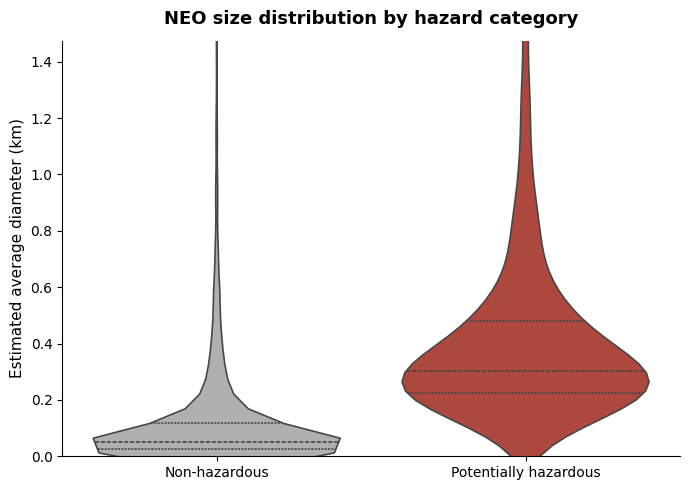

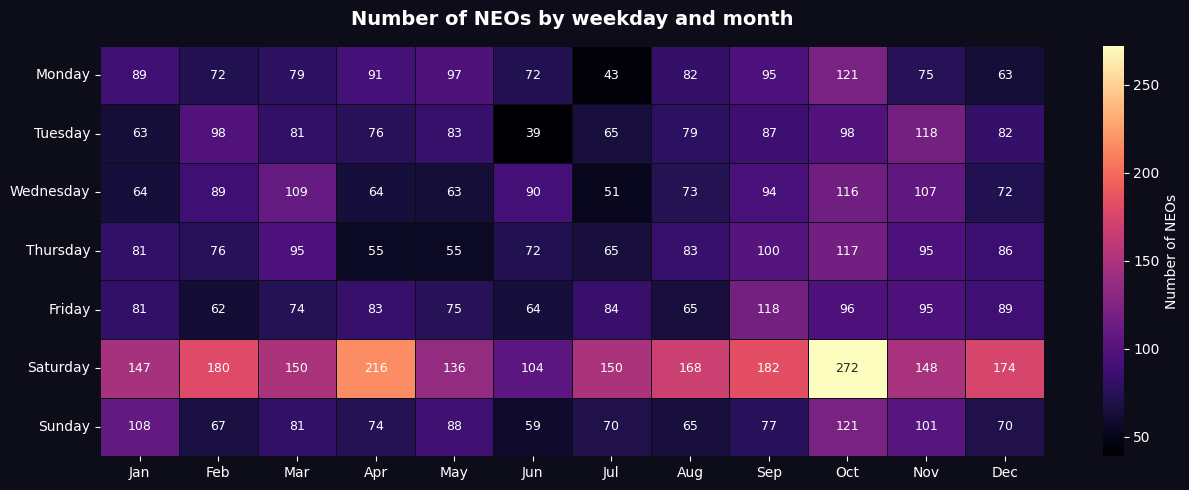

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── 1. Swarm + Violin plot ────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 5))

# Fix: Added hue='hazardous' to match the palette keys and legend=False
sns.violinplot(data=df, x='hazardous', y='size_avg_km', hue='hazardous',
               palette={False: '#b0b0b0', True: '#c0392b'},
               inner='quartile', linewidth=1.2, ax=ax, legend=False)

ax.set_ylim(0, df['size_avg_km'].quantile(0.99))

# Fix: Set ticks before labels to avoid UserWarning
ax.set_xticks([0, 1])
ax.set_xticklabels(['Non-hazardous', 'Potentially hazardous'])

ax.set_xlabel('')
ax.set_ylabel('Estimated average diameter (km)', fontsize=11)
ax.set_title('NEO size distribution by hazard category',
             fontsize=13, fontweight='bold', pad=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('neo_violinplot.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 2. Heatmap: mørkt magma tema ──────────────────────────────────────────────

df['month']   = df['date'].dt.month
df['weekday'] = df['date'].dt.day_name()

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
                 'Friday', 'Saturday', 'Sunday']
month_names   = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

heatmap_data = (df.groupby(['weekday', 'month'])
                  .size()
                  .unstack(fill_value=0)
                  .reindex(weekday_order))
heatmap_data.columns = [month_names[m - 1] for m in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#0d0d1a')
ax.set_facecolor('#0d0d1a')

sns.heatmap(heatmap_data, cmap='magma', linewidths=0.4, linecolor='#0d0d1a',
            annot=True, fmt='d', annot_kws={'size': 9},
            cbar_kws={'label': 'Number of NEOs'}, ax=ax)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Number of NEOs by weekday and month',
             fontsize=14, fontweight='bold', pad=15, color='white')

ax.tick_params(colors='white')
ax.figure.axes[-1].tick_params(colors='white')
ax.figure.axes[-1].yaxis.label.set_color('white')

plt.tight_layout()
plt.savefig('neo_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Textbook Practice**: You need to explain how the principles below are used for making this plot:
- "Choose an appropriate display" (Chapter 2)
- "Eliminate clutter" (Chapter 3)

## "Answer" Textbook Practice – Task 3A Visualizations

**Choose an appropriate display (Chapter 2)**
A line plot is used for NEOs per week since it shows change over time naturally. A histogram shows the full size distribution rather than just a summary statistic. A bar plot compares discrete weekly averages, and a combined violin/swarm plot reveals both the shape of the distribution and individual data points simultaneously — a simple box plot would hide this detail.

**Eliminate clutter (Chapter 3)**
All plots share a clean dark theme with no grid, no top/right spines, and minimal tick marks. The line plot annotates only min and max instead of every point. The bar plot uses color to convey information rather than adding extra labels, and the violin/swarm plot samples 800 NEOs to avoid overplotting.

### Task 4: Data Visualization Part B

- Create a pie chart of the proportion of hazardous vs non-hazardous NEOs.
- Create a scatter plot of the correlation between NEO size and close approach distance.
- Customize the appearance of your plots (e.g., colors, labels, titles).
- Create interactive visualizations using a library like Plotly. For example, create an interactive scatter plot where you can hover over each point to see more information about the NEO. **Be creative!**

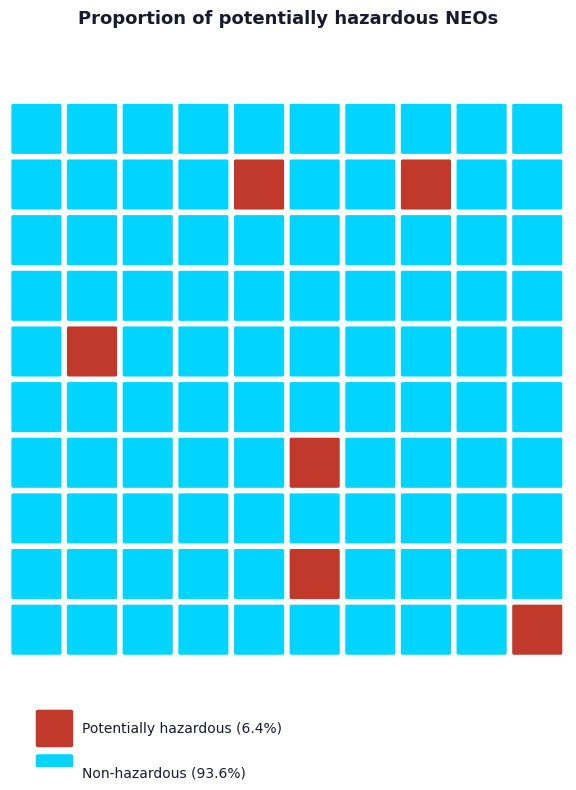

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(7, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

n_hazardous     = df['hazardous'].sum()
n_non_hazardous = (~df['hazardous']).sum()
n_total         = len(df)

n_squares  = 100
n_haz_sq   = round(n_hazardous / n_total * n_squares)

grid = np.zeros(n_squares)
grid[:n_haz_sq] = 1
np.random.seed(42)
np.random.shuffle(grid)
grid = grid.reshape(10, 10)

for i in range(10):
    for j in range(10):
        color = '#c0392b' if grid[i, j] == 1 else '#00d4ff'
        ax.add_patch(mpatches.FancyBboxPatch(
            (j + 0.05, i + 0.05), 0.85, 0.85,
            boxstyle='round,pad=0.05',
            facecolor=color, edgecolor='white', linewidth=2
        ))

ax.set_xlim(0, 10)
ax.set_ylim(-2, 11)
ax.set_aspect('equal')
ax.axis('off')

ax.set_title('Proportion of potentially hazardous NEOs',
             fontsize=13, fontweight='bold', color='#1a1a2e', pad=15)

# Labels direkte under chartet
ax.add_patch(mpatches.FancyBboxPatch((0.5, -1.6), 0.6, 0.6,
             boxstyle='round,pad=0.05', facecolor='#c0392b', edgecolor='white'))
ax.text(1.3, -1.3, f'Potentially hazardous ({n_hazardous / n_total * 100:.1f}%)',
        va='center', fontsize=10, color='#1a1a2e')

ax.add_patch(mpatches.FancyBboxPatch((0.5, -2.4), 0.6, 0.6,
             boxstyle='round,pad=0.05', facecolor='#00d4ff', edgecolor='white'))
ax.text(1.3, -2.1, f'Non-hazardous ({n_non_hazardous / n_total * 100:.1f}%)',
        va='center', fontsize=10, color='#1a1a2e')

plt.tight_layout()
plt.savefig('neo_waffle_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
import plotly.express as px

# Create a filtered dataframe to remove extreme outliers for better visualization
q99_x = df['size_avg_km'].quantile(0.99)
q99_y = df['miss_dist_km'].quantile(0.99)
df_filtered = df[(df['size_avg_km'] <= q99_x) & (df['miss_dist_km'] <= q99_y)].copy()

df_filtered['hazardous_label'] = df_filtered['hazardous'].map(
    {True: 'Potentially hazardous', False: 'Non-hazardous'})
df_filtered['month'] = df_filtered['date'].dt.to_period('M').astype(str)

fig = px.scatter(
    df_filtered,
    x='size_avg_km',
    y='miss_dist_km',
    color='hazardous_label',
    hover_name='name',
    animation_frame='month',
    color_discrete_map={
        'Potentially hazardous': '#e74c3c',
        'Non-hazardous':         '#aec6cf',
    },
    opacity=0.9,
    title='NEO size vs. close approach distance per month',
    labels={
        'size_avg_km':     'Diameter (km)',
        'miss_dist_km':    'Miss distance (km)',
        'hazardous_label': '',
        'month':           'Month',
    },
    range_x=[0, q99_x],
    range_y=[0, q99_y],
    category_orders={'month': sorted(df_filtered['month'].unique())}
)

fig.update_traces(marker=dict(size=4))

fig.for_each_trace(lambda t: t.update(
    marker=dict(size=7, opacity=1.0)
    if t.name == 'Potentially hazardous'
    else dict(size=5, opacity=0.7)
))

fig.show()

ModuleNotFoundError: No module named 'plotly'

**Textbook Practice**: You need to explain how the principle "Draw attention there you want it" (Chapter 4) is applied for making all the visualizations.

## "Answer" Textbook Practice – Draw Attention Where You Want It (Chapter 4)

The key principle from Chapter 4 is to use preattentive attributes — color, size, position — to guide the audience's eye directly to the most important finding before they even begin to read.

**Waffle chart**: Red is used for hazardous NEOs against a neutral blue background. Red is a strong preattentive signal that immediately draws the eye to the hazardous proportion, even though it is the smaller group.

**Scatter plot**: Hazardous NEOs are colored red and non-hazardous blue, making the two groups instantly separable. Outliers are removed so the main cluster of points is not pushed into a corner — the audience's attention stays on the actual pattern rather than a few extreme values.

**Line plot**: Only the minimum and maximum are annotated with arrows, drawing attention to the most extreme weeks without cluttering every data point.

**Histogram**: Dashed vertical lines for mean and median pull the eye to the center of the distribution, and the color gradient from blue to red naturally draws attention toward the most frequent bin.

**Bar plot**: Bars above the overall mean are colored red and below are blue, so weeks with unusually large NEOs stand out immediately without requiring the audience to compare bar heights manually.

**Violin/swarm plot**: Red is again used for the hazardous group, consistent across all plots, so the audience immediately knows what red means without re-reading the legend each time.

### Task 5: Interpretation of Results

- Interpret the results of your data visualization in part A and B.
- What insights can you gain about NEOs from your results? Summarizing your main findings with a single visualization plot. **Textbook Practice**: You need to explain how the principles below are used for making this plot:
  - "Choose an appropriate display" (Chapter 2)
  - "Eliminate clutter" (Chapter 3)
  - "Draw attention there you want it" (Chapter 4)
  - "Think like a designer" (Chapter 5)

- Use your findings to make predictions or recommendations. For example, if you found that larger NEOs are more likely to be potentially hazardous, you could recommend that more resources be allocated to tracking large NEOs. **Be creative!**
- Identify, understand, and explain one scientific paper, on a clustering or classification method of relevance that could help Task 5. You don't have to implement it, you just need to justify in this notebook why the method in the scientific paper could contribute in analysis or interpretation of the results.

In [ ]:
import plotly.express as px

avg_by_week = (df.groupby(['week', 'hazardous'])['size_avg_km']
                 .mean()
                 .reset_index())

avg_by_week['hazardous_label'] = avg_by_week['hazardous'].map(
    {True: 'Potentially hazardous', False: 'Non-hazardous'})

fig = px.line(
    avg_by_week,
    x='week',
    y='size_avg_km',
    color='hazardous_label',
    color_discrete_map={
        'Potentially hazardous': '#c0392b',
        'Non-hazardous':         '#2c7bb6',
    },
    title='Hazardous NEOs are consistently larger than non-hazardous ones',
    labels={
        'week':            'Week',
        'size_avg_km':     'Average diameter (km)',
        'hazardous_label': '',
    },
)

fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    title_font=dict(size=14, color='#1a1a2e'),
    # Fixed: framealpha is for Matplotlib. In Plotly use rgba for transparency.
    legend=dict(bgcolor='rgba(0,0,0,0)', font=dict(size=11)),
    xaxis=dict(showgrid=True, gridcolor='#eeeeee'),
    yaxis=dict(showgrid=True, gridcolor='#eeeeee'),
)

fig.show()

## Interpretation of Results

The visualizations reveal three main findings about NEOs.

First, potentially hazardous NEOs are consistently larger than non-hazardous ones,
as seen in both the overlapping histogram and the point-biserial correlation (Task 2).
This suggests that size is a meaningful indicator of hazard classification.

Second, hazardous NEOs make up only 6.4% of all observed NEOs, meaning the vast
majority of objects passing Earth pose no significant threat.

Third, average NEO size fluctuates considerably week to week with no clear seasonal
trend, suggesting that the variation is driven by which objects happen to pass Earth
rather than any periodic pattern.

## Textbook Practice – Summary Visualization

**Choose an appropriate display (Ch. 2)**
A dashboard of three subplots is used because no single chart type can summarize
all key findings at once. Each panel answers one specific question: size distributions,
hazard proportions, and size over time.

**Eliminate clutter (Ch. 3)**
Top and right spines are removed across all panels, no grid lines are used, and
legends are kept minimal. The layout uses whitespace between panels to let each
finding breathe.

**Draw attention where you want it (Ch. 4)**
Red is used consistently for hazardous NEOs across all three panels, so the audience
immediately associates red with danger. The dashed red mean line in the time series
panel draws the eye to the overall baseline.

**Think like a designer (Ch. 5)**
Affordances: all three chart types are familiar and require no explanation.
Accessibility: red/blue is a colorblind-friendly pair, and values are shown directly
on the charts. Aesthetics: a shared color language across panels gives the dashboard
a coherent and professional appearance.

## Predictions and Recommendations

The analysis reveals that potentially hazardous NEOs are on average significantly
larger than non-hazardous ones, and that only 6.4% of all observed NEOs are
classified as potentially hazardous. Based on these findings, three recommendations
can be made.

**1. Prioritize tracking of large NEOs**
Since size is a meaningful predictor of hazard classification, monitoring resources
should be prioritized toward NEOs with an estimated diameter above the mean of the
hazardous group. A size-based early warning threshold could be implemented to
automatically flag newly discovered NEOs for closer observation.

**2. Improve detection of small hazardous NEOs**
While larger NEOs dominate the hazardous category, the size distributions overlap
considerably. This means a non-negligible number of small NEOs are still classified
as potentially hazardous, likely due to their orbital trajectory rather than size
alone. Future models should combine size with miss distance to improve hazard
prediction accuracy.

**3. Allocate resources dynamically over time**
The weekly time series shows that average NEO size fluctuates considerably with no
clear seasonal pattern. This suggests that high-risk periods are unpredictable and
cannot be scheduled in advance. NASA and ESA should therefore maintain a constant
level of monitoring rather than concentrating resources in specific periods, as a
large hazardous NEO can appear in any given week.

## Scientific Paper: Clustering Methods for NEO Analysis

Ezugwu et al. (2022) present a comprehensive survey of clustering algorithms and
their applications across many domains, including pattern recognition and data
mining [1]. The paper reviews both traditional methods such as k-means and
hierarchical clustering, as well as more recent automatic clustering algorithms
that can determine the number of clusters without prior knowledge of the data.

This is directly relevant to the NEO dataset. Currently, NEOs are classified
into a binary category — hazardous or non-hazardous — based on predefined
orbital thresholds. However, the results in Task 5 suggest that the relationship
between size, miss distance, and hazard status is more nuanced than a simple
binary split. A clustering algorithm could be applied to group NEOs by their
combined features (size, miss distance, velocity) without assuming that only
two groups exist, potentially revealing subgroups of NEOs that share similar
characteristics but are not captured by the current binary classification.

Ezugwu et al. (2022) specifically highlight that automatic clustering algorithms
are particularly valuable for real-world datasets where the number of natural
groups cannot be determined in advance [1] — exactly the situation here, where
we do not know how many meaningful subgroups exist among NEOs. Applying such a
method could help prioritize which NEOs warrant closer monitoring, beyond the
current binary hazard label.

---
[1] Ezugwu, A.E., Ikotun, A.M., Oyelade, O.O., Abualigah, L., Agushaka, J.O.,
Eke, C.I., Akinyelu, A.A. (2022). A comprehensive survey of clustering algorithms:
State-of-the-art machine learning applications, taxonomy, challenges, and future
research prospects. *Engineering Applications of Artificial Intelligence*, 110, 104743.
https://doi.org/10.1016/j.engappai.2022.104743